In [653]:
from __future__ import absolute_import, division, print_function
import iotbx.pdb
import iotbx.mrcfile
import mmtbx.model
import mmtbx.real_space
from scitbx.array_family import flex
from cctbx.development import random_structure
from cctbx import sgtbx
from cctbx import maptbx
import random
import numpy as np
from scipy.fft import fftn, ifftn

In [654]:
def create_random_structure():
    # Create random structure
    n = np.random.randint(10, 30)
    elements = list(np.random.choice(['C', 'N', 'Cl', 'O'], size = n))

    xrs = random_structure.xray_structure(
            elements = elements,
            space_group_info = sgtbx.space_group_info("P21"),
            volume_per_atom = 20,
            random_u_iso=True
        )
    return xrs



def calculate_patterson_fft(xrs, d_min=0.8, map_shape=(14, 14, 14)):
    """
    Calculate Patterson map using FFT method.
    
    Args:
        xrs: X-ray structure object
        d_min: Resolution limit (default: 0.8)
        map_shape: Base shape of the map (will be doubled) (default: (14,14,14))
    
    Returns:
        patterson_fft: Calculated Patterson map
        central_slice: Central slice of the Patterson map
    """
    # Get structure factor amplitudes and convert to numpy array
    f_calc = xrs.structure_factors(d_min=d_min).f_calc().as_intensity_array()
    f_obs = abs(f_calc).data().as_numpy_array()
    miller_indices = np.array(f_calc.indices())

    # Create 3D grid for structure factors
    #map_shape = tuple([i*2 for i in map_shape])
    nx, ny, nz = map_shape
    F_grid = np.zeros((nx, ny, nz), dtype=np.complex128)

    # Place F^2 values on 3D grid at corresponding Miller indices
    for i, (h, k, l) in enumerate(miller_indices):
        F_squared = f_obs[i]#**2
        
        # Generate equivalent reflections based on P21 symmetry
        equiv_hkls = get_equivalent_reflections(h, k, l)
        
        # Place F^2 at all equivalent positions
        for h_eq, k_eq, l_eq in equiv_hkls:
            # Convert indices to positive ones using modulo
            h_idx = h_eq % nx
            k_idx = k_eq % ny
            l_idx = l_eq % nz
            F_grid[h_idx, k_idx, l_idx] = F_squared

    # Calculate Patterson map using FFT
    patterson_fft = np.real(ifftn(F_grid)) / xrs.unit_cell().volume()
    #patterson_fft = np.where(patterson_fft < 0, 0, patterson_fft)
    patterson_fft = (patterson_fft - patterson_fft.min()) / (patterson_fft.max() - patterson_fft.min())
    
    return patterson_fft

def get_equivalent_reflections(h, k, l):
    if k==0 and l==0:
        return [(h, 0, 0), (-h, 0, 0)]
    elif h==0 and l==0:
        return [(0, k, 0), (0, -k, 0)]
    elif h==0 and k==0:
        return [(0, 0, l), (0, 0, -l)]
    elif k == 0:
        return [(h, 0, l), (-h, 0, -l)]
    else:
        return [(h, k, l), (-h, k, -l), (-h, -k, -l), (h, -k, l)]

def recover_intensities_from_patterson(xrs, patterson_map, miller_indices):
    """
    Recover structure factor intensities from Patterson map using FFT.
    
    Args:
        xrs: X-ray structure object
        patterson_map: 3D numpy array containing Patterson map
        miller_indices: Array of Miller indices (h,k,l)
    
    Returns:
        recovered_intensities: Array of recovered |F|² values
    """
    # Forward FFT of Patterson map
    F_recovered = fftn(patterson_map)
    
    # Get dimensions of Patterson map
    nx, ny, nz = patterson_map.shape
    
    # Initialize array for recovered intensities
    recovered_intensities = np.zeros(len(miller_indices))
    
    # Extract intensities at Miller indices positions
    for idx, (h, k, l) in enumerate(miller_indices):
        # Convert to positive indices using modulo
        h_idx = h % nx
        k_idx = k % ny
        l_idx = l % nz
        
        # Get the intensity value from the FFT grid
        recovered_intensities[idx] = np.abs(F_recovered[h_idx, k_idx, l_idx])
    
    # Normalize intensities
    recovered_intensities *= xrs.unit_cell().volume()
    
    return recovered_intensities

In [655]:
soot09, soot08, soot15 = np.zeros(1000), np.zeros(1000), np.zeros(1000)
for i in range(1000):
    xrs = create_random_structure()
    
    # Calculate original intensities
    ints08 = xrs.structure_factors(d_min=0.8).f_calc().as_intensity_array().data().as_numpy_array().shape[0]
    ints09 = xrs.structure_factors(d_min=0.9).f_calc().as_intensity_array().data().as_numpy_array().shape[0]
    ints10 = xrs.structure_factors(d_min=1.0).f_calc().as_intensity_array().data().as_numpy_array().shape[0]
    ints15 = xrs.structure_factors(d_min=1.5).f_calc().as_intensity_array().data().as_numpy_array().shape[0]
    soot08[i] = ints08/ints10
    soot09[i] = ints09/ints10
    soot15[i] = ints15/ints10

In [656]:
soot08.mean(), soot09.mean(), soot15.mean()

(1.9256672443292187, 1.3612738307023522, 0.3064831948404347)

In [657]:
ints08, ints09, ints10, ints15

(2505, 1767, 1303, 394)

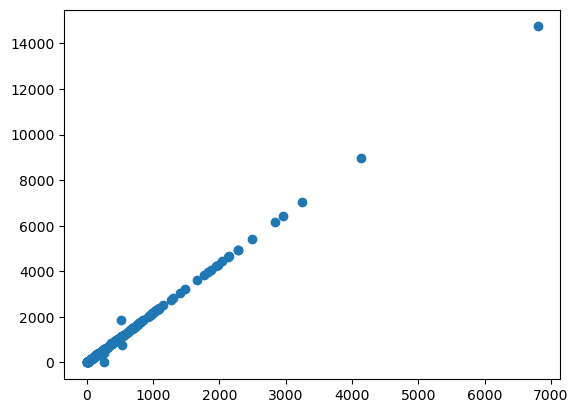

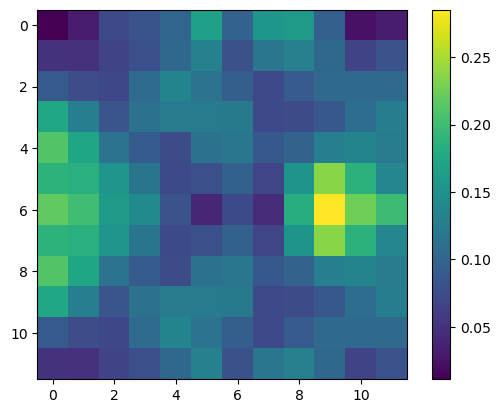

0.0 1.0


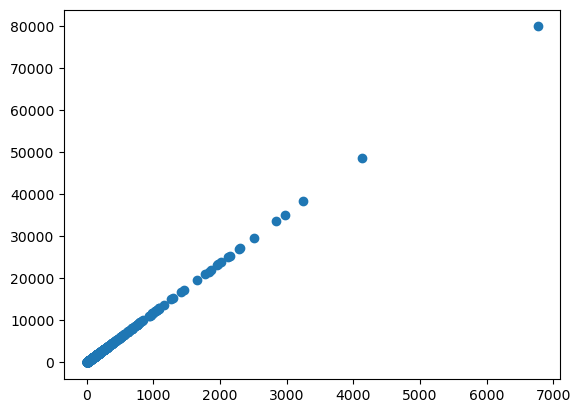

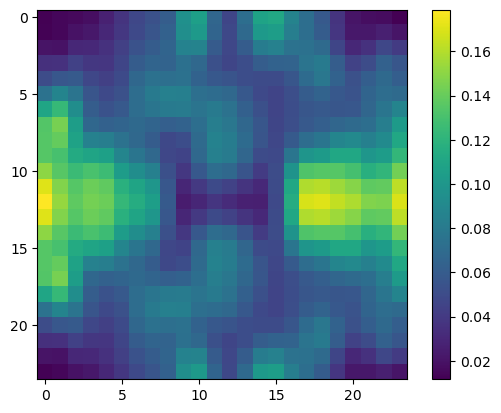

0.0 1.0


In [658]:
dmin = 1.5
map_shape = (12, 12, 12)
xrs = create_random_structure()
patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)


import matplotlib.pyplot as plt
plt.scatter((xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()), recovered_intensities)
plt.show()
plt.imshow(patterson_map[11//2, :, :])
plt.colorbar()
plt.show()
print(patterson_map.min(), patterson_map.max())

patterson_map = calculate_patterson_fft(xrs, d_min=1.0, map_shape=(24,24,24))
miller_indices = np.array(xrs.structure_factors(d_min=1.0).f_calc().indices())
recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)


import matplotlib.pyplot as plt
plt.scatter((xrs.structure_factors(d_min=1.0).f_calc().as_intensity_array().data().as_numpy_array()), recovered_intensities)
plt.show()
plt.imshow(patterson_map[22//2, :, :])
plt.colorbar()
plt.show()
print(patterson_map.min(), patterson_map.max())

In [659]:
dmin = 1.5
map_shape = (15, 15, 15)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(100)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(100):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 0.999


In [660]:
dmin = 1.5
map_shape = (14, 14, 14)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

Mean correlation coefficient: 0.997
Worst correlation coefficient: 0.914
Best correlation coefficient: 1.000
Error in callback <function flush_figures at 0x767b0a309f80> (for post_execute):


KeyboardInterrupt: 

Mean correlation coefficient: 1.000
Worst correlation coefficient: 0.995
Best correlation coefficient: 1.000


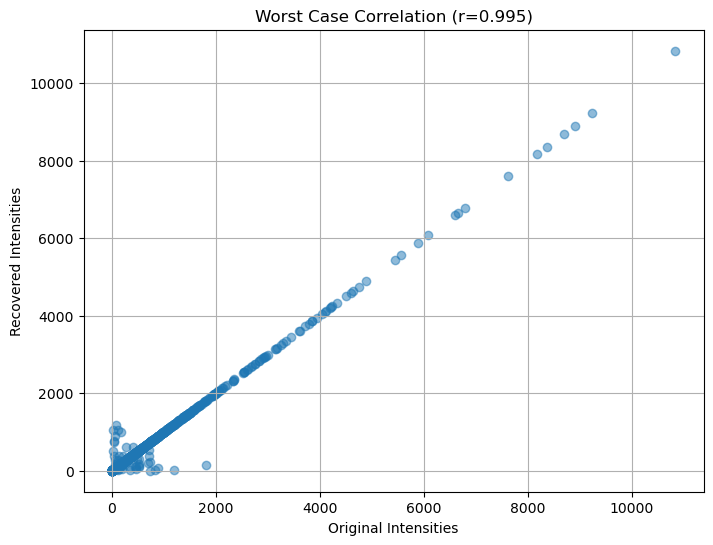

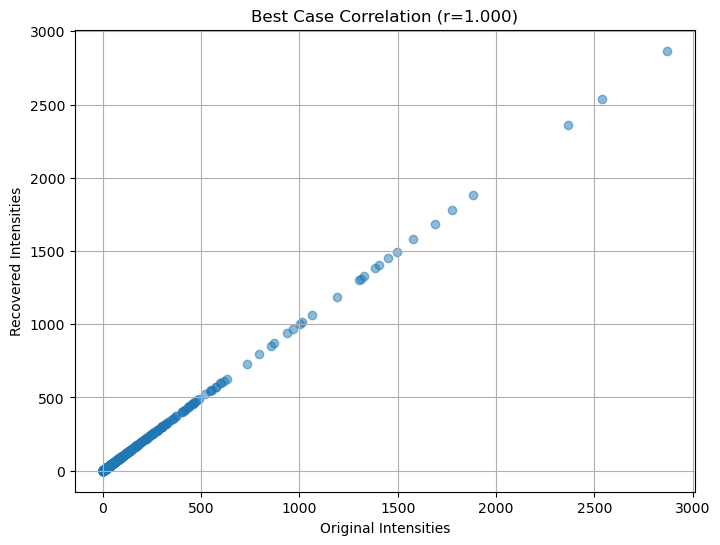

In [622]:
dmin = 1.0
map_shape = (22, 22, 22)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

Mean correlation coefficient: 0.989
Worst correlation coefficient: 0.871
Best correlation coefficient: 1.000


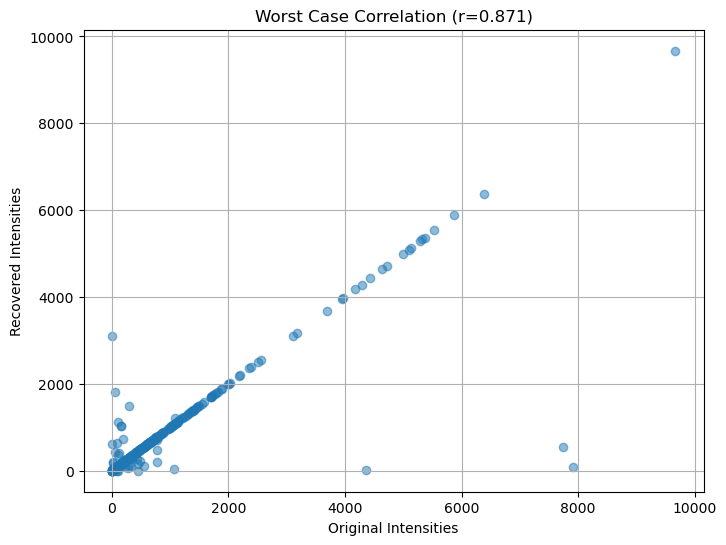

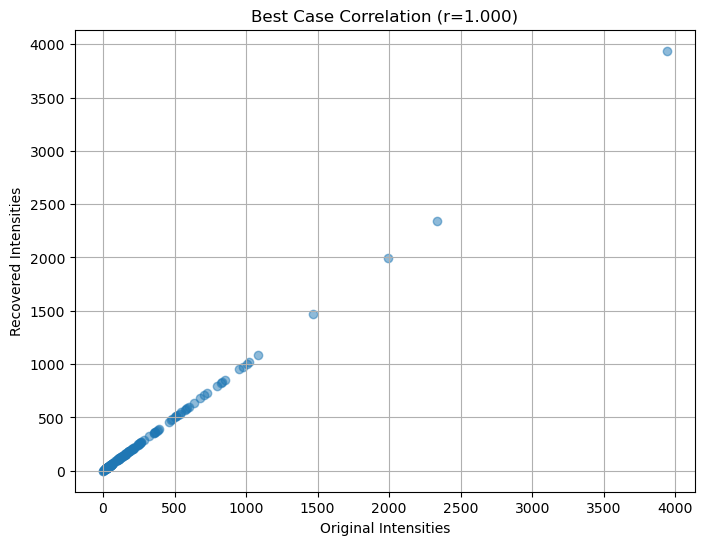

In [620]:
dmin = 1.5
map_shape = (13, 13, 13)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

Mean correlation coefficient: 1.000
Worst correlation coefficient: 0.991
Best correlation coefficient: 1.000


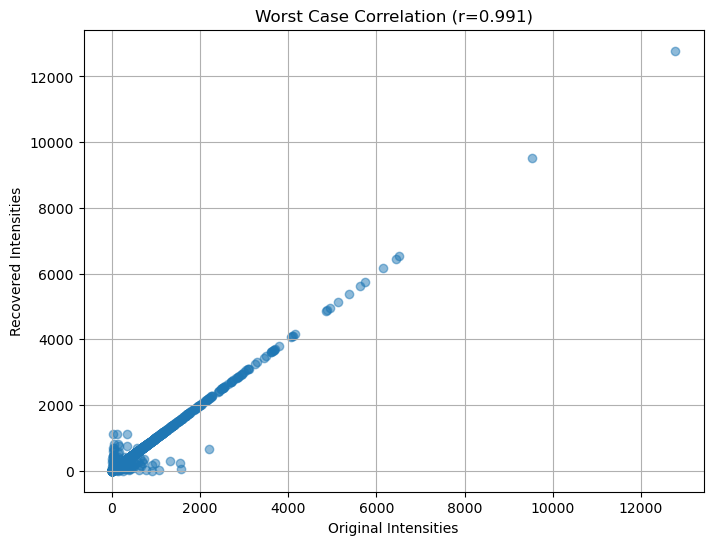

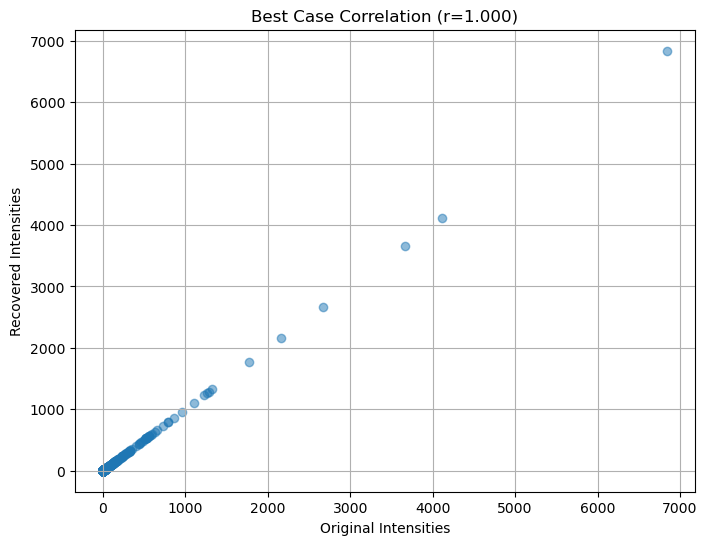

In [601]:
dmin = 0.8
map_shape = (26, 26, 26)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

Mean correlation coefficient: 1.000
Worst correlation coefficient: 0.998
Best correlation coefficient: 1.000


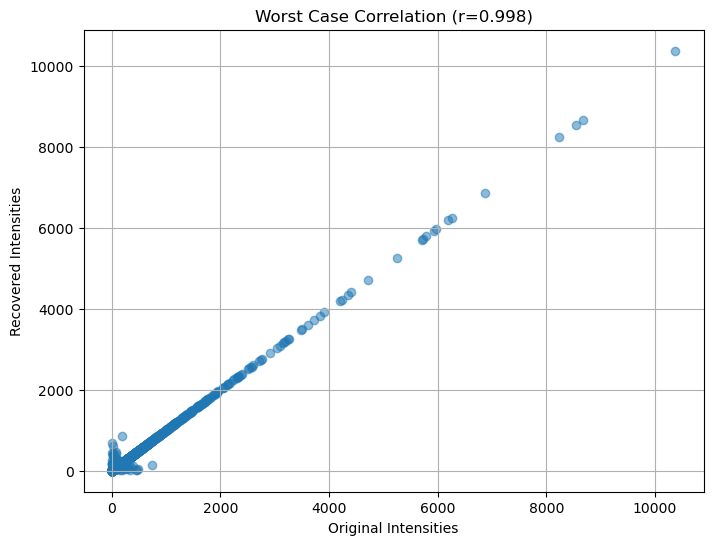

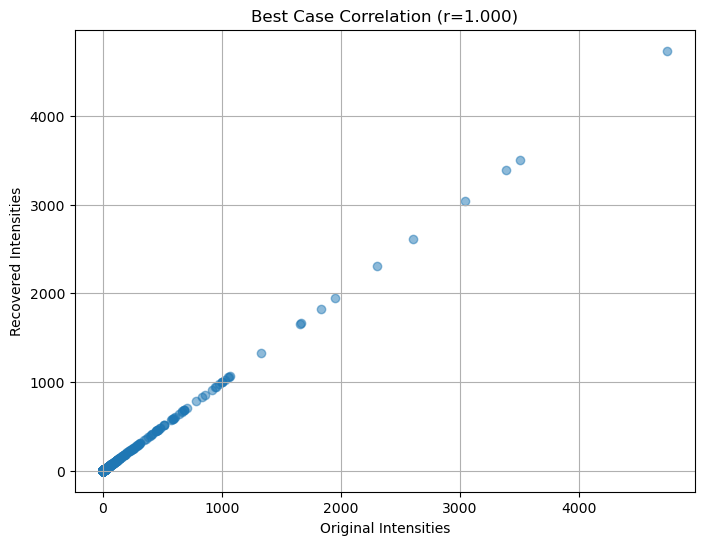

In [600]:
dmin = 0.8
map_shape = (28, 28, 28)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

Mean correlation coefficient: 1.000
Worst correlation coefficient: 0.999
Best correlation coefficient: 1.000


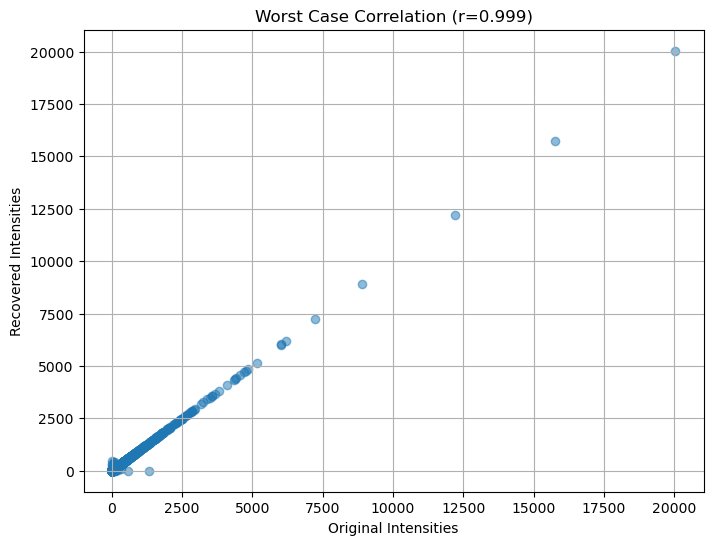

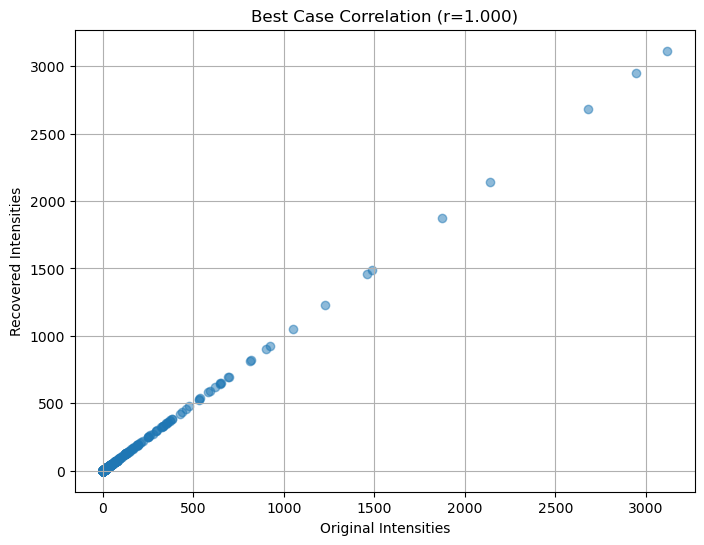

In [599]:
dmin = 0.8
map_shape = (30, 30, 30)

# Initialize array to store correlation coefficients and intensities
corrcoefs = np.zeros(1000)
all_original_intensities = []
all_recovered_intensities = []

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef
    assert original_intensities.shape == recovered_intensities.shape
    
    # Store intensities
    all_original_intensities.append(original_intensities)
    all_recovered_intensities.append(recovered_intensities)

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

# Find indices of best and worst correlation coefficients
worst_idx = np.argmin(corrcoefs)
best_idx = np.argmax(corrcoefs)

# Plot scatter for worst case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[worst_idx], all_recovered_intensities[worst_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Worst Case Correlation (r={corrcoefs[worst_idx]:.3f})')
plt.grid(True)

# Plot scatter for best case
plt.figure(figsize=(8, 6))
plt.scatter(all_original_intensities[best_idx], all_recovered_intensities[best_idx], alpha=0.5)
plt.xlabel('Original Intensities')
plt.ylabel('Recovered Intensities')
plt.title(f'Best Case Correlation (r={corrcoefs[best_idx]:.3f})')
plt.grid(True)

print(f"Worst correlation coefficient: {corrcoefs[worst_idx]:.3f}")
print(f"Best correlation coefficient: {corrcoefs[best_idx]:.3f}")

In [591]:
dmin = 1.5
map_shape = (12, 12, 12)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(1000)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 0.973


In [584]:
dmin = 0.8
map_shape = (24, 24, 24)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(1000)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 0.999


In [585]:
dmin = 0.8
map_shape = (26, 26, 26)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(1000)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 1.000


In [586]:
dmin = 0.8
map_shape = (28, 28, 28)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(1000)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 1.000


In [587]:
dmin = 0.8
map_shape = (30, 30, 30)

# Initialize array to store correlation coefficients
corrcoefs = np.zeros(1000)

# Generate 100 structures and calculate correlation coefficient for each
for i in range(1000):
    xrs = create_random_structure()
    patterson_map = calculate_patterson_fft(xrs, d_min=dmin, map_shape=map_shape)
    miller_indices = np.array(xrs.structure_factors(d_min=dmin).f_calc().indices())
    recovered_intensities = recover_intensities_from_patterson(xrs, patterson_map, miller_indices)
    
    # Calculate original intensities
    original_intensities = xrs.structure_factors(d_min=dmin).f_calc().as_intensity_array().data().as_numpy_array()
    
    # Calculate correlation coefficient
    corrcoef = np.corrcoef(original_intensities, recovered_intensities)[0,1]
    corrcoefs[i] = corrcoef

# Print mean correlation coefficient
print(f"Mean correlation coefficient: {np.mean(corrcoefs):.3f}")

Mean correlation coefficient: 1.000


In [405]:
# Create random structure
n = np.random.randint(10, 30)
elements = list(np.random.choice(['C', 'N', 'Cl', 'O'], size = n))

xrs = random_structure.xray_structure(
            elements = elements,
            space_group_info = sgtbx.space_group_info("P21"),
            volume_per_atom = 20,
            random_u_iso=True
        )


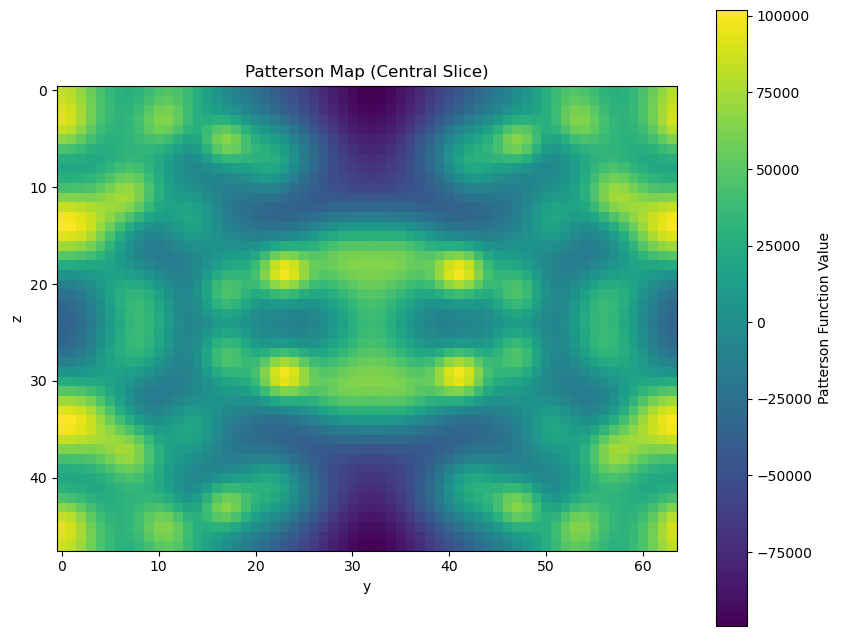

Unit cell:  (7.38027, 9.59435, 12.5465, 90, 109, 90)
Map size:  (40, 48, 64)


In [406]:
# Calculate structure factors
f_calc = xrs.structure_factors(d_min=0.8).f_calc()

# Calculate Patterson map
patterson = f_calc.patterson_map(
    symmetry_flags=maptbx.use_space_group_symmetry,
    resolution_factor=0.25
)

# Get map data as flex array and convert to numpy array
map_data = patterson.real_map_unpadded()
map_data_np = map_data.as_numpy_array()

# Visualize Patterson map using matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Get central slice of 3D map data
central_slice = map_data_np[map_data_np.shape[0]//2,:,:]

# Create figure and plot
plt.figure(figsize=(10,8))
plt.imshow(central_slice, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Patterson Function Value')
plt.title('Patterson Map (Central Slice)')
plt.xlabel('y')
plt.ylabel('z') 
plt.show()

print("Unit cell: ", patterson.unit_cell())
print("Map size: ", map_data.all())


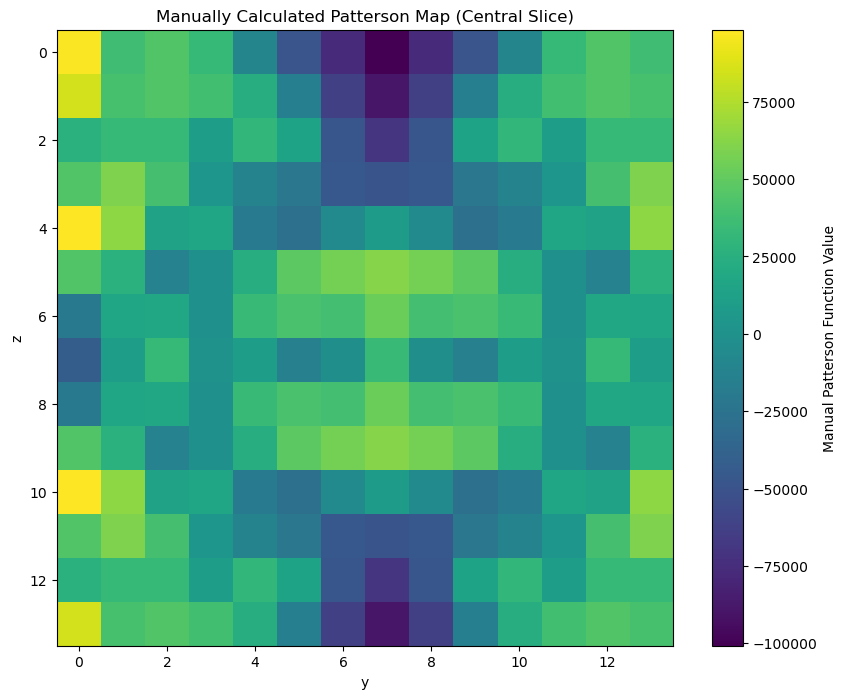

In [407]:
def get_equivalent_reflections(h, k, l):
    if k==0 and l==0:
        return [(h, 0, 0), (-h, 0, 0)]
    elif h==0 and l==0:
        return [(0, k, 0), (0, -k, 0)]
    elif h==0 and k==0:
        return [(0, 0, l), (0, 0, -l)]
    elif k == 0:
        return [(h, 0, l), (-h, 0, -l)]
    else:
        return [(h, k, l), (-h, k, -l), (-h, -k, -l), (h, -k, l)]

# Manual calculation of Patterson map
# Get structure factor amplitudes and convert to numpy array
f_calc_low = xrs.structure_factors(d_min=1.5).f_calc()
f_obs_low = abs(f_calc_low).data().as_numpy_array()

# Get Miller indices and convert to numpy array
miller_indices_low = np.array(f_calc_low.indices())

# Create 3D grid for Patterson map
map_shape = (14, 14, 14)
nx, ny, nz = map_shape
patterson_manual = np.zeros((nx, ny, nz))

# Calculate Patterson function manually
# P(u,v,w) = 1/V * sum(|F(h,k,l)|^2 * cos(2pi*(hu + kv + lw)))
for i in range(len(f_obs_low)):
    h, k, l = miller_indices_low[i]
    F_squared = f_obs_low[i]**2
    
    # Generate equivalent reflections based on symmetry
    equiv_hkls = get_equivalent_reflections(h, k, l)


    for u in range(nx):
        for v in range(ny):
            for w in range(nz):
                # Convert grid indices to fractional coordinates
                uf = u/nx
                vf = v/ny
                wf = w/nz
                
                # Sum over all equivalent reflections
                for h_eq, k_eq, l_eq in equiv_hkls:
                    # Calculate phase term
                    phase = 2*np.pi*(h_eq*uf + k_eq*vf + l_eq*wf)
                    patterson_manual[u,v,w] += F_squared * np.cos(phase)

# Normalize - divide by 4 times number of reflections due to symmetry equivalents
#patterson_manual /= (4 * len(f_obs))

# Visualize manual Patterson map
plt.figure(figsize=(10,8))
central_slice_manual = patterson_manual[patterson_manual.shape[0]//2,:,:]
plt.imshow(central_slice_manual, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Manual Patterson Function Value')
plt.title('Manually Calculated Patterson Map (Central Slice)')
plt.xlabel('y')
plt.ylabel('z')
plt.show()

# Compare with the built-in calculation
#print("\nCorrelation coefficient between manual and built-in Patterson maps:",
#      np.corrcoef(central_slice.flatten(), central_slice_manual.flatten())[0,1])


In [408]:
#np.corrcoef(map_data_np.flatten(), patterson_manual.flatten())[0,1]

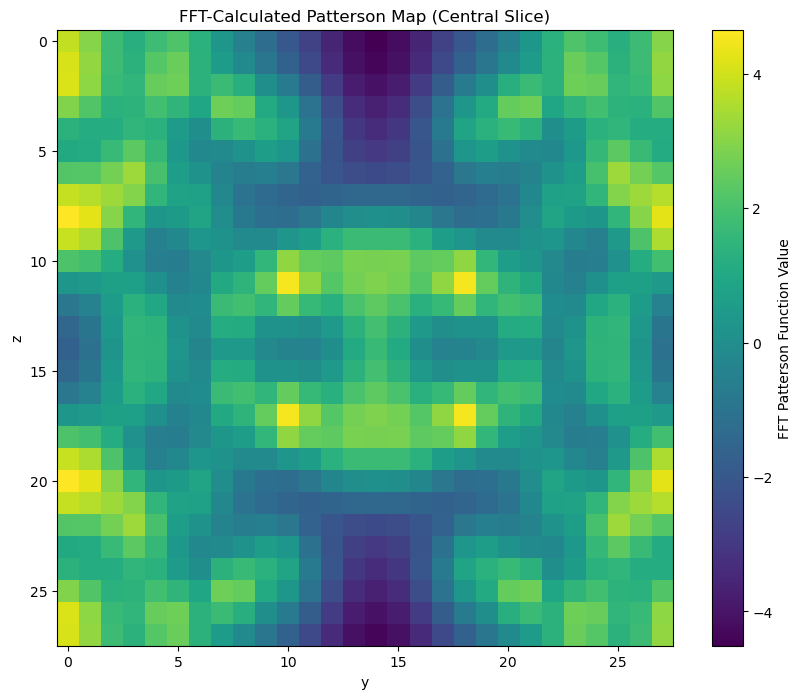

Correlation coefficient between FFT and manual Patterson maps: NaN


In [409]:
# Get structure factor amplitudes and convert to numpy array
f_calc_high = xrs.structure_factors(d_min=0.8).f_calc()
f_obs_high = abs(f_calc_high).data().as_numpy_array()
miller_indices_high = np.array(f_calc_high.indices())

# Create 3D grid for structure factors
map_shape_high = tuple([i*2 for i in map_shape])
nx, ny, nz = map_shape_high
F_grid = np.zeros((nx, ny, nz), dtype=np.complex128)

# Place F^2 values on 3D grid at corresponding Miller indices
for i, (h, k, l) in enumerate(miller_indices_high):
    F_squared = f_obs_high[i]**2
    
    # Generate equivalent reflections based on P21 symmetry
    equiv_hkls = get_equivalent_reflections(h, k, l)
    
    # Place F^2 at all equivalent positions
    for h_eq, k_eq, l_eq in equiv_hkls:
        # Convert indices to positive ones using modulo
        h_idx = h_eq % nx
        k_idx = k_eq % ny
        l_idx = l_eq % nz
        F_grid[h_idx, k_idx, l_idx] = F_squared

# Calculate Patterson map using FFT
from scipy.fft import ifftn
patterson_fft = np.real(ifftn(F_grid))

# Normalize by volume
#patterson_fft /= (nx * ny * nz)

# Visualize FFT-calculated Patterson map
plt.figure(figsize=(10,8))
central_slice_fft = patterson_fft[patterson_fft.shape[0]//2,:,:]
plt.imshow(central_slice_fft, cmap='viridis', interpolation='nearest')
plt.colorbar(label='FFT Patterson Function Value')
plt.title('FFT-Calculated Patterson Map (Central Slice)')
plt.xlabel('y')
plt.ylabel('z')
plt.show()

# Compare with manual calculation
try:
    print("\nCorrelation coefficient between FFT and manual Patterson maps:",
          np.corrcoef(patterson_manual.flatten(), patterson_fft.flatten()[::2])[0,1])
except:
    print("Correlation coefficient between FFT and manual Patterson maps: NaN")

# Compare with built-in calculation
#print("Correlation coefficient between FFT and built-in Patterson maps:",
#      np.corrcoef(map_data_np.flatten(), patterson_fft.flatten())[0,1])

In [410]:
# Get structure factors from Patterson map using FFT
from scipy.fft import fftn

# Forward FFT of Patterson map
F_recovered = fftn(patterson_manual)

# Initialize array for recovered intensities
F_squared_array = f_obs_low**2
recovered_intensities = np.zeros_like(F_squared_array)

# Extract intensities at Miller indices positions
for idx, (h, k, l) in enumerate(miller_indices_low):
    # Convert to positive indices using modulo
    h_idx = h % nx
    k_idx = k % ny
    l_idx = l % nz
    
    # Get the intensity value from the FFT grid
    recovered_intensities[idx] = np.abs(F_recovered[h_idx, k_idx, l_idx]) / (nx * ny * nz)
recovered_intensities /= recovered_intensities.max()
# Compare original and recovered intensities
plt.figure(figsize=(8,8))
plt.scatter(F_squared_array, recovered_intensities)
plt.plot([0, F_squared_array.max()], [0, F_squared_array.max()], 'r--')  # Perfect correlation line
plt.xlabel('Original |F|²')
plt.ylabel('Recovered |F|²')
plt.title('Original vs Recovered Intensities')
plt.show()

print("Correlation coefficient:", 
      np.corrcoef(F_squared_array, recovered_intensities)[0,1])

IndexError: index 24 is out of bounds for axis 0 with size 14

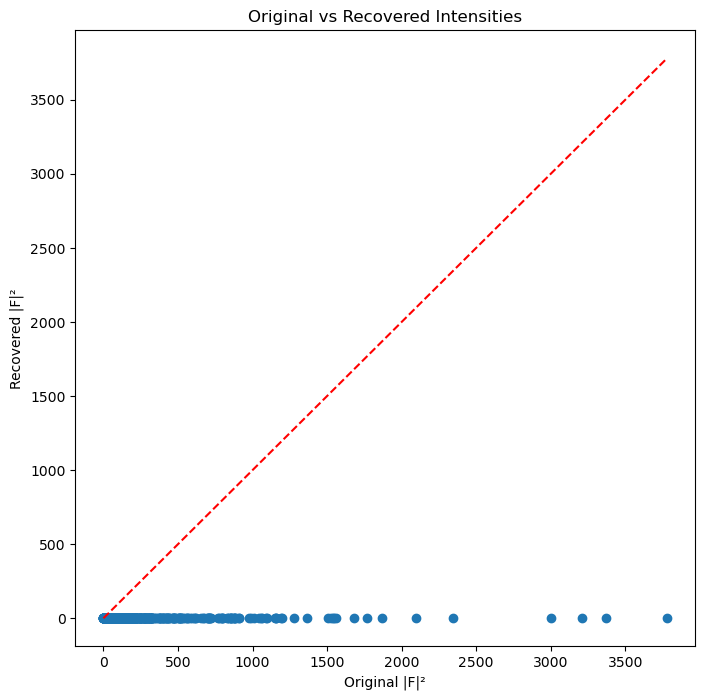

Correlation coefficient: 1.0


In [403]:
# Get structure factors from Patterson map using FFT
from scipy.fft import fftn

# Forward FFT of Patterson map
F_recovered = fftn(patterson_fft)
F_squared_array = f_obs_high**2
# Initialize array for recovered intensities
recovered_intensities = np.zeros_like(F_squared_array)

# Extract intensities at Miller indices positions
for idx, (h, k, l) in enumerate(miller_indices_high):
    # Convert to positive indices using modulo
    h_idx = h % nx
    k_idx = k % ny
    l_idx = l % nz
    
    # Get the intensity value from the FFT grid
    recovered_intensities[idx] = np.abs(F_recovered[h_idx, k_idx, l_idx]) / (nx * ny * nz)
recovered_intensities /= recovered_intensities.max()
# Compare original and recovered intensities
plt.figure(figsize=(8,8))
plt.scatter(F_squared_array, recovered_intensities)
plt.plot([0, F_squared_array.max()], [0, F_squared_array.max()], 'r--')  # Perfect correlation line
plt.xlabel('Original |F|²')
plt.ylabel('Recovered |F|²')
plt.title('Original vs Recovered Intensities')
plt.show()

print("Correlation coefficient:", 
      np.corrcoef(F_squared_array, recovered_intensities)[0,1])

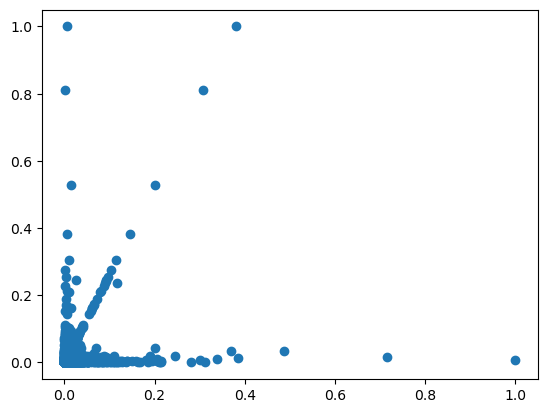

In [368]:
plt.scatter(F_squared_array.flatten(), recovered_intensities.flatten())

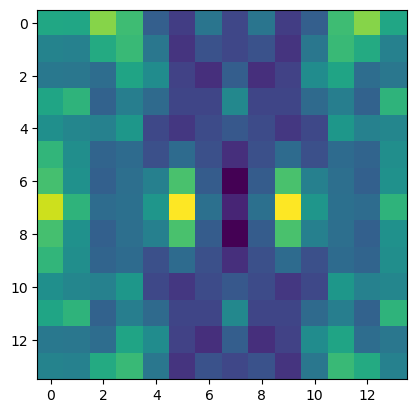

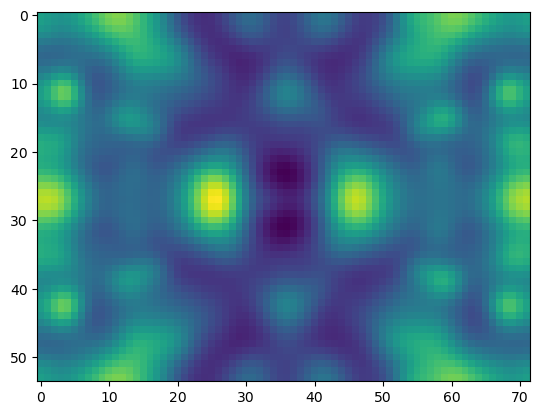

In [369]:
plt.imshow(central_slice_manual, cmap='viridis')
plt.show()
plt.imshow(central_slice, cmap='viridis')
plt.show()

In [370]:
map_data_np.shape, patterson_manual.shape


((45, 54, 72), (14, 14, 14))

ValueError: x and y must be the same size

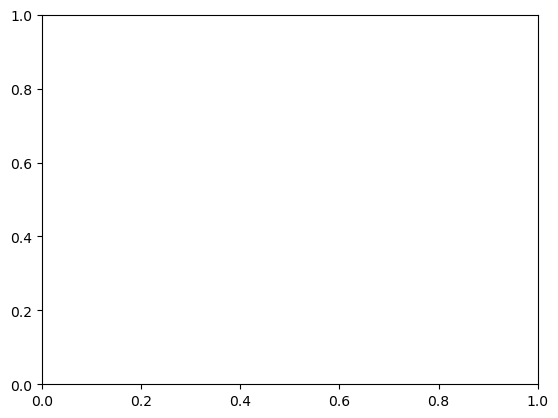

In [371]:
plt.scatter(map_data_np.flatten(), patterson_manual.flatten())

In [10]:
print("\nCorrelation coefficient between manual and built-in Patterson maps:",
      np.corrcoef(map_data_np.flatten(), patterson_manual.flatten())[0,1])



Correlation coefficient between manual and built-in Patterson maps: 1.0


In [11]:
F_squared_array = f_obs**2
F_squared_array.shape

(28,)

In [12]:
# Inverse transformation from Patterson map to structure factors
# Initialize array for recovered intensities
recovered_intensities = np.zeros_like(F_squared_array)

# Get dimensions of Patterson map
nx, ny, nz = patterson_manual.shape

# For each reflection
for idx, (h, k, l) in enumerate(f_calc.indices()):
    # Get equivalent reflections using crystal symmetry
    equiv_hkls = [
        (h, k, l),     # Original hkl
        (-h, k, -l),   # -hk-l
        (-h, -k, -l),  # -h-k-l 
        (h, -k, l)     # h-kl
    ]
    
    # Initialize sum for this reflection
    intensity_sum = 0
    
    # Perform inverse Fourier transform
    for u in range(nx):
        for v in range(ny):
            for w in range(nz):
                # Convert grid indices to fractional coordinates
                uf = u/nx
                vf = v/ny
                wf = w/nz
                
                # Sum over all equivalent reflections
                for h_eq, k_eq, l_eq in equiv_hkls:
                    # Calculate phase term
                    phase = 2*np.pi*(h_eq*uf + k_eq*vf + l_eq*wf)
                    # Should use complex exponential instead of just cosine
                    intensity_sum += patterson_manual[u,v,w] * (np.cos(phase) + 1j * np.sin(phase))
    
    # Store recovered intensity - need to take absolute value of complex number
    recovered_intensities[idx] = np.abs(intensity_sum) / (nx * ny * nz)

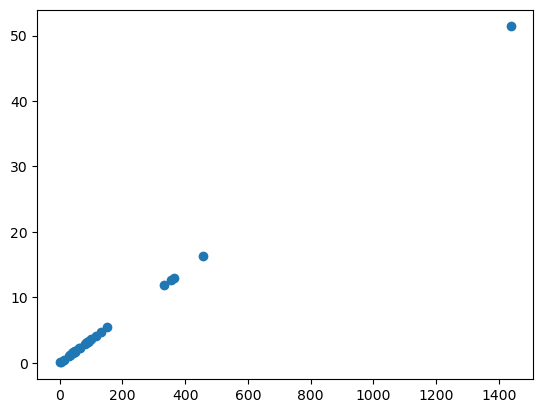

In [13]:
plt.scatter(F_squared_array, recovered_intensities)